## Reference Data: Allen Brain Atlas — Mouse V1 & ALM Smart-seq

Single-cell RNA-seq transcriptomic dataset from the Allen Cell Types Database, profiling cells from mouse primary visual cortex (VISp / V1) and anterior lateral motor cortex (ALM).

- **Species:** Mouse (*Mus musculus*)
- **Brain regions:** Primary visual cortex (VISp, 14,249 cells) and anterior lateral motor cortex (ALM, 9,573 cells) — **23,822 cells total**
- **Method:** Smart-seq full-length scRNA-seq
- **Cell types:** 133 transcriptomic types total
  - 56 glutamatergic (excitatory) neuron types — mostly region-specific
  - 61 GABAergic (inhibitory) neuron types — mostly shared across regions
  - 16 non-neuronal types — mostly shared across regions
- **Source:** [Allen Brain Map — Mouse V1 and ALM Smart-seq](https://brain-map.org/our-research/cell-types-taxonomies/cell-types-database-rna-seq-data/mouse-v1-and-alm-smart-seq)

VISp and ALM represent distant poles of the neocortex with distinct functions, making this dataset well-suited for studying transcriptional diversity and region-specific cell type organization. Used here as a reference taxonomy for annotating HCR/FISH spatial data.

---

## Subclass Exclusions

The following subclasses are excluded from analysis:

| Subclass | Reason |
|----------|--------|
| Astro | Astrocytes — non-neuronal glial cells |
| Oligo | Oligodendrocytes — non-neuronal glial cells |
| Endo | Endothelial cells — vascular, non-neuronal |
| Peri | Pericytes — vascular, non-neuronal |
| VLMC | Vascular leptomeningeal cells — non-neuronal |
| SMC | Smooth muscle cells — vascular, non-neuronal |
| Macrophage | Immune cells — non-neuronal |
| Doublet | Two cells captured together — sequencing artifact |
| Low Quality | Failed QC thresholds — low reads or gene detection |
| No Class | Outlier or donor-specific cluster — unassignable |


bain_subregion
	"L1"
	"L1-L2/3"
	"L1-L4"
	"L1-L6"
	"L2/3"
	"L2/3-L4"
	"L4"
	"L4-L5"
	"L4-L6"
	"L5"
	"L5-L6"
	"L6"
	"L6b"

In [14]:
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import seaborn as sns


import sys, importlib
sys.path.insert(0, '/root/capsule/code/cluster_validation')
import atlas_compare


In [40]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:

from typing import Literal

def load_visp_expression(
    data_dir: str | Path,
    genes: list[str] | None = None,
    layer: Literal["sum", "exon", "intron"] = "sum",
) -> ad.AnnData:
    """
    Load Allen Brain Atlas VISp Smart-seq gene expression data as AnnData.

    Parameters
    ----------
    data_dir : path to the extracted dataset folder
    genes : list of gene symbols to load (e.g. ['Nos1', 'Vip']).
            If None, loads all genes (warning: large).
    layer : which counts to use for X — 'exon', 'intron', or 'sum' (default).

    Returns
    -------
    AnnData with:
      - X        : counts per `layer` (cells × genes, float32)
      - obs      : sample_name (index), class, subclass, cluster, brain_region, brain_subregion
      - var      : gene_symbol (index), gene_id, chromosome, gene_entrez_id, gene_name
    Only Glutamatergic and GABAergic cells are included.
    """
    if layer not in ("sum", "exon", "intron"):
        raise ValueError(f"layer must be 'sum', 'exon', or 'intron'; got {layer!r}")

    data_dir = Path(data_dir)
    prefix = "mouse_VISp_2018-06-14"

    # --- gene metadata ---
    genes_df = pl.read_csv(data_dir / f"{prefix}_genes-rows.csv")
    # columns: gene_symbol, gene_id, chromosome, gene_entrez_id, gene_name

    if genes is not None:
        genes_df = genes_df.filter(pl.col("gene_symbol").is_in(genes))
        if genes_df.is_empty():
            raise ValueError(f"None of the requested genes were found: {genes}")

    target_entrez = set(genes_df["gene_entrez_id"].cast(pl.Utf8).to_list())

    # --- cell metadata ---
    meta_df = (
        pl.read_csv(
            data_dir / f"{prefix}_samples-columns.csv",
            null_values=["NA"],
        )
        .select(["sample_name", "class", "subclass", "cluster", "brain_region", "brain_subregion"])
        .filter(pl.col("class").is_in(["Glutamatergic", "GABAergic"]))
    )
    neuronal_cell_ids = set(meta_df["sample_name"].to_list())

    # --- expression matrix: rows=genes, cols=cells ---
    need_exon = layer in ("sum", "exon")
    need_intron = layer in ("sum", "intron")

    row_id_col = None

    if need_exon:
        exon_full = pl.read_csv(data_dir / f"{prefix}_exon-matrix.csv", infer_schema_length=0)
        row_id_col = exon_full.columns[0]
        exon_sub = exon_full.filter(pl.col(row_id_col).is_in(target_entrez))
    if need_intron:
        intron_full = pl.read_csv(data_dir / f"{prefix}_intron-matrix.csv", infer_schema_length=0)
        row_id_col = intron_full.columns[0]
        intron_sub = intron_full.filter(pl.col(row_id_col).is_in(target_entrez))

    entrez_to_symbol = dict(
        zip(
            genes_df["gene_entrez_id"].cast(pl.Utf8).to_list(),
            genes_df["gene_symbol"].to_list(),
        )
    )

    ref_full = exon_full if need_exon else intron_full
    all_cell_ids = ref_full.columns[1:]
    keep_col_idx = [i for i, cid in enumerate(all_cell_ids) if cid in neuronal_cell_ids]
    keep_cell_ids = [all_cell_ids[i] for i in keep_col_idx]

    gene_symbols = []
    count_rows = []

    if layer == "sum":
        rows = zip(exon_sub.iter_rows(), intron_sub.iter_rows())
        for row_e, row_i in rows:
            entrez_id = row_e[0]
            all_counts = [int(e) + int(i) for e, i in zip(row_e[1:], row_i[1:])]
            count_rows.append([all_counts[i] for i in keep_col_idx])
            gene_symbols.append(entrez_to_symbol[entrez_id])
    elif layer == "exon":
        for row in exon_sub.iter_rows():
            entrez_id = row[0]
            all_counts = [int(v) for v in row[1:]]
            count_rows.append([all_counts[i] for i in keep_col_idx])
            gene_symbols.append(entrez_to_symbol[entrez_id])
    else:  # intron
        for row in intron_sub.iter_rows():
            entrez_id = row[0]
            all_counts = [int(v) for v in row[1:]]
            count_rows.append([all_counts[i] for i in keep_col_idx])
            gene_symbols.append(entrez_to_symbol[entrez_id])

    # Build X as (n_cells, n_genes)
    X = np.array(count_rows, dtype=np.float32).T

    obs = (
        meta_df.to_pandas()
        .set_index("sample_name")
        .loc[keep_cell_ids]
    )
    var = (
        genes_df.to_pandas()
        .set_index("gene_symbol")
        .loc[gene_symbols]
    )

    adata = ad.AnnData(X=X, obs=obs, var=var)
    adata.uns["layer"] = layer
    return adata


def plot_cell_count_by_subregion(adata: ad.AnnData) -> plt.Figure:
    sns.set_context("notebook", font_scale=1.2)

    counts = (
        adata.obs
        .groupby(["brain_subregion", "class"])
        .size()
        .reset_index(name="cell_count")
        .sort_values("brain_subregion")
    )

    subregion_order = (
        counts.groupby("brain_subregion")["cell_count"]
        .sum()
        .sort_values(ascending=False)
        .index.tolist()
    )

    class_colors = {"Glutamatergic": "#E07B39", "GABAergic": "#4878CF"}

    fig, ax = plt.subplots(figsize=(6, max(4, len(subregion_order) * 0.4)))

    lefts = {sr: 0 for sr in subregion_order}
    for cls, color in class_colors.items():
        cls_counts = counts[counts["class"] == cls].set_index("brain_subregion")["cell_count"]
        values = [cls_counts.get(sr, 0) for sr in subregion_order]
        ax.barh(subregion_order, values, left=[lefts[sr] for sr in subregion_order],
                color=color, label=cls)
        for sr, v in zip(subregion_order, values):
            lefts[sr] += v

    ax.set_xlabel("Cell count")
    ax.set_title("Cell count per brain subregion")
    ax.legend(title="Class")
    plt.tight_layout()
    return fig


def filter_subclass(
    adata: ad.AnnData,
    exclude_subclasses: set[str] | None = None,
    exclude_brain_regions: set[str] | None = None,
) -> ad.AnnData:
    obs = adata.obs
    mask = obs["subclass"].notna().values
    if exclude_subclasses:
        mask &= ~obs["subclass"].isin(exclude_subclasses).values
    if exclude_brain_regions:
        mask &= ~obs["brain_subregion"].isin(exclude_brain_regions).values
    return adata[mask].copy()


def plot_subclass_heatmap(
    adata: ad.AnnData,
    title: str,
) -> plt.Figure:
    gene_cols = adata.var_names.tolist()
    subclasses = sorted(adata.obs["subclass"].dropna().unique())

    heatmap_data = np.zeros((len(subclasses), len(gene_cols)))
    for i, sc_name in enumerate(subclasses):
        mask = adata.obs["subclass"].values == sc_name
        heatmap_data[i] = adata.X[mask].mean(axis=0)

    fig, ax = plt.subplots(figsize=(len(gene_cols) * .5, len(subclasses) * 0.35 + 1))
    im = ax.imshow(heatmap_data, aspect="auto", cmap="magma")

    ax.set_xticks(range(len(gene_cols)))
    ax.set_xticklabels(gene_cols, rotation=90, ha="right")
    ax.set_yticks(range(len(subclasses)))
    ax.set_yticklabels(subclasses)
    ax.set_xlabel("Gene")
    ax.set_ylabel("Subclass")
    ax.set_title(title)

    plt.colorbar(im, ax=ax, label="Mean expression")
    plt.tight_layout()
    return fig





def make_filtered_views_for_smartseq(adata: ad.AnnData) -> dict[str, ad.AnnData]:
    """
    Return a dict of filtered AnnData views.

    Keys
    ----
    "all"        : neuronal cells, non-neuronal subclasses and deep-layer regions removed
    "inhibitory" : GABAergic subclasses only (Pvalb, Sst, Vip, Lamp5, ...)
    "excitatory" : Glutamatergic cells only
    """

    # --- filter configuration ---
    _exclude_subclasses = {
        "VLMC", "Peri", "Oligo", "SMC", "No Class",
        "Macrophage", "Low Quality", "Endo", "Doublet", "Astro",
        "High Intronic", "Batch Grouping"
    }
    _exclude_brain_regions = {"L6", "L6b"}
    _inh_subclasses = {"Pvalb", "Sst", "Vip", "Lamp5", "CR", "Serpinf1", "Sncg", "Meis2"}

    base = filter_subclass(adata, _exclude_subclasses, _exclude_brain_regions)
    return {
        "all": base,
        "inhibitory": base[base.obs["subclass"].isin(_inh_subclasses)].copy(),
        "excitatory": base[base.obs["class"] == "Glutamatergic"].copy(),
    }

In [17]:
smartseq_path = "/root/capsule/scratch/mouse_VISp_gene_expression_matrices_2018-06-14"

marker_genes = ['Slc17a7', 'Ndnf', 'Hpse', 'Pthlh', 'Chat', 'Tac1', 'Calb1', 'Mme',
 'Crh', 'Reln', 'Tac2', 'Lamp5', 'Calb2', 'Pdyn', 'Penk', 'Gad2', 'Npy', 'Pvalb',
 'Cck', 'Sst', 'Vip']

adata = load_visp_expression(smartseq_path, genes=marker_genes, layer="exon")
adata


AnnData object with n_obs × n_vars = 13491 × 21
    obs: 'class', 'subclass', 'cluster', 'brain_region', 'brain_subregion'
    var: 'gene_id', 'chromosome', 'gene_entrez_id', 'gene_name'
    uns: 'layer'

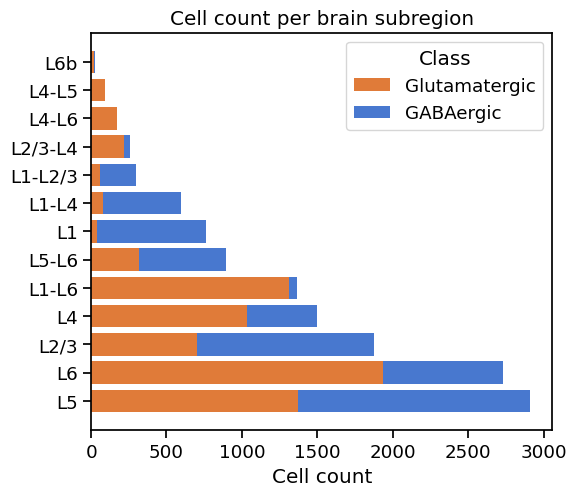

In [18]:
fig = plot_cell_count_by_subregion(adata)
plt.show()


In [19]:
gene_cols = adata.var_names.tolist()

# CPM: normalize each cell's counts to sum to 1e6
adata_cpm = adata.copy()
sc.pp.normalize_total(adata_cpm, target_sum=1e6)

# log2(CPM + 1)
adata_log = adata_cpm.copy()
sc.pp.log1p(adata_log, base=2)


In [ ]:
# Filtering is now applied at the end of the cell above (filter_subclass definition cell).
# adata_log_filtered, adata_cpm_filtered are ready to use.


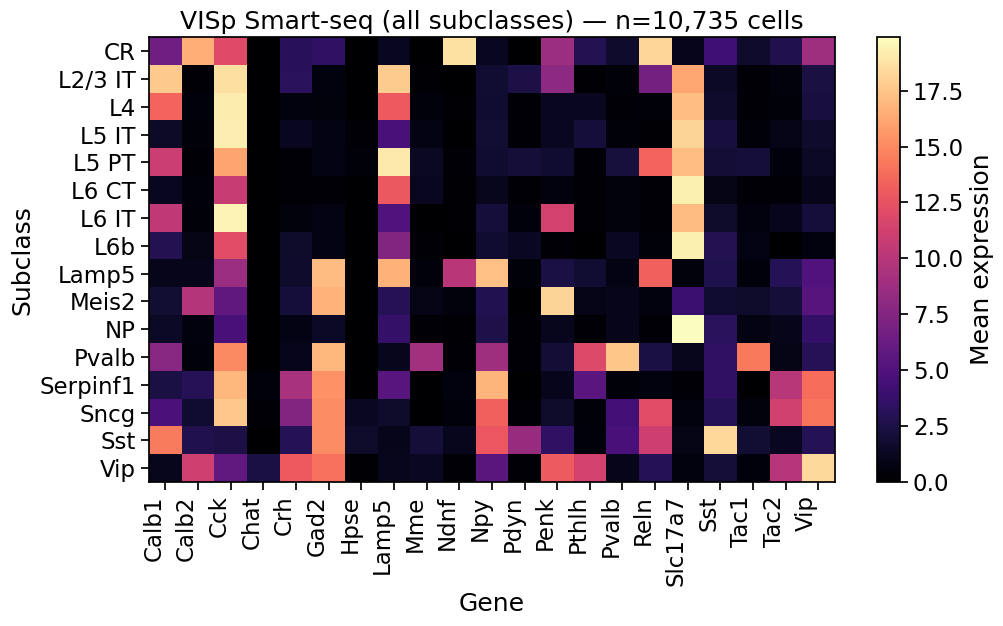

In [20]:
sns.set_context("notebook", font_scale=1.5)

filtered_log = make_filtered_views_for_smartseq(adata_log)
filtered_cpm = make_filtered_views_for_smartseq(adata_cpm)

fig = plot_subclass_heatmap(filtered_log["all"], title=f"VISp Smart-seq (all subclasses) — n={len(filtered_log['all']):,} cells")
plt.show()


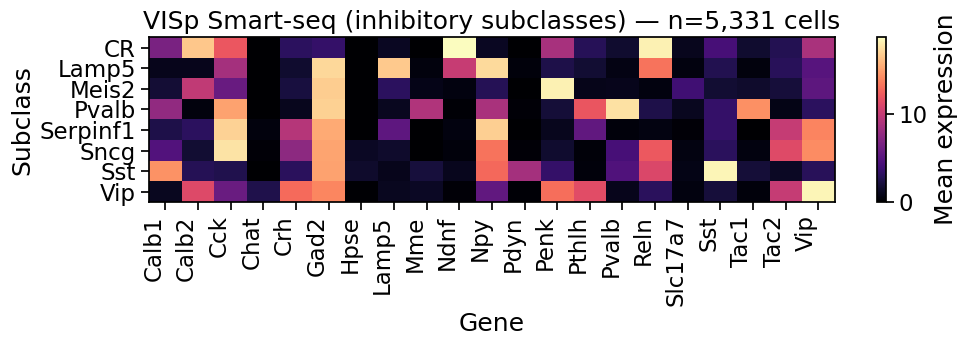

In [21]:
fig = plot_subclass_heatmap(filtered_log["inhibitory"], 
                            title=f"VISp Smart-seq (inhibitory subclasses) — n={len(filtered_log['inhibitory']):,} cells")
plt.show()


# Cell x gene

(<Figure size 700x1000 with 2 Axes>,
 array([ 0,  0,  0, ..., 19, 19, 19], shape=(5331,)),
 Index(['F1S4_160108_002_H01', 'F1S4_160108_001_D01', 'F1S4_160108_004_D01',
        'F2S4_160115_026_H01', 'FYS4_171003_504_D01', 'F1S4_160108_006_E01',
        'F2S4_170807_009_A01', 'F2S4_170807_006_G01', 'F2S4_170807_007_B01',
        'F2S4_160121_003_D01',
        ...
        'F2S4_160727_002_E01', 'F2S4_180122_027_D01', 'F2S4_170526_016_H01',
        'F1S4_160108_011_B01', 'F2S4_160404_011_D01', 'F2S4_160404_008_H01',
        'F2S4_180312_009_F01', 'F2S4_180312_009_H01', 'F2S4_180312_010_B01',
        'F2S4_180312_010_F01'],
       dtype='object', name='sample_name', length=5331))

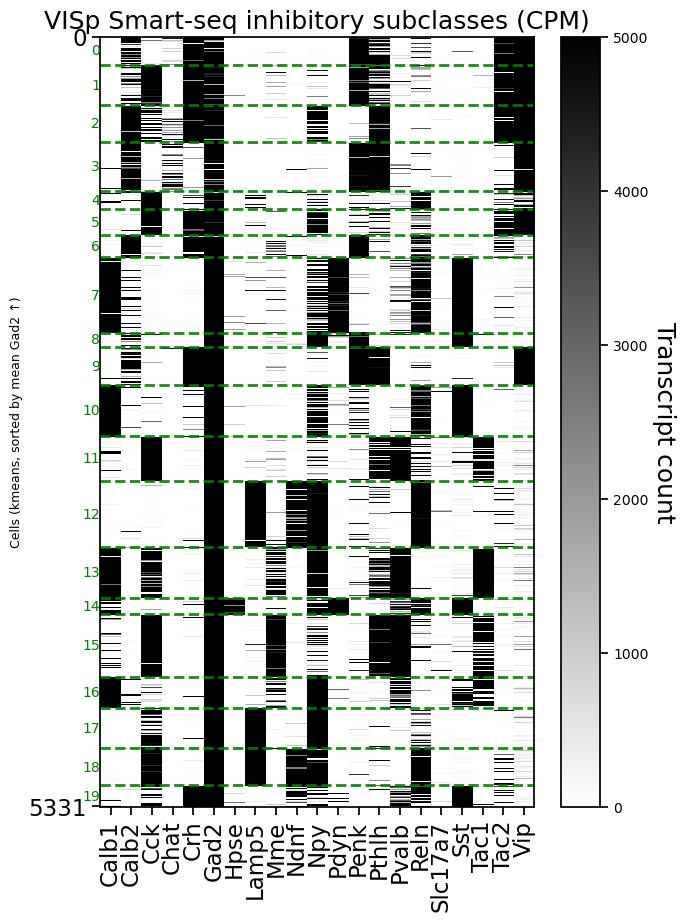

In [22]:
import pandas as pd
import aind_hcr_qc.viz as viz

inh_cpm = filtered_cpm["inhibitory"]
viz.plot_cell_x_gene_clustered(
    pd.DataFrame(inh_cpm.X, columns=inh_cpm.var_names, index=inh_cpm.obs_names),
    k=20, fig_size=(7, 10), title="VISp Smart-seq inhibitory subclasses (CPM)",
    clip_range=(0, 5000))


(<Figure size 700x1000 with 2 Axes>,
 array([ 0,  0,  0, ..., 19, 19, 19], shape=(5331,)),
 Index(['F2S4_160119_005_F01', 'F2S4_160119_005_A01', 'F2S4_160121_001_G01',
        'F2S4_160119_009_C01', 'F2S4_171128_004_A01', 'F2S4_171128_001_G01',
        'F2S4_161017_001_G01', 'F2S4_161017_001_A01', 'F2S4_161017_004_C01',
        'F2S4_161017_003_D01',
        ...
        'F2S4_160404_019_B01', 'F2S4_170803_016_F01', 'F2S4_151223_016_F01',
        'F1S4_180124_308_E01', 'F1S4_180124_308_C01', 'F1S4_180124_307_H01',
        'F2S4_151223_017_B01', 'F2S4_160404_028_C01', 'F2S4_160404_029_H01',
        'F2S4_160404_032_F01'],
       dtype='object', name='sample_name', length=5331))

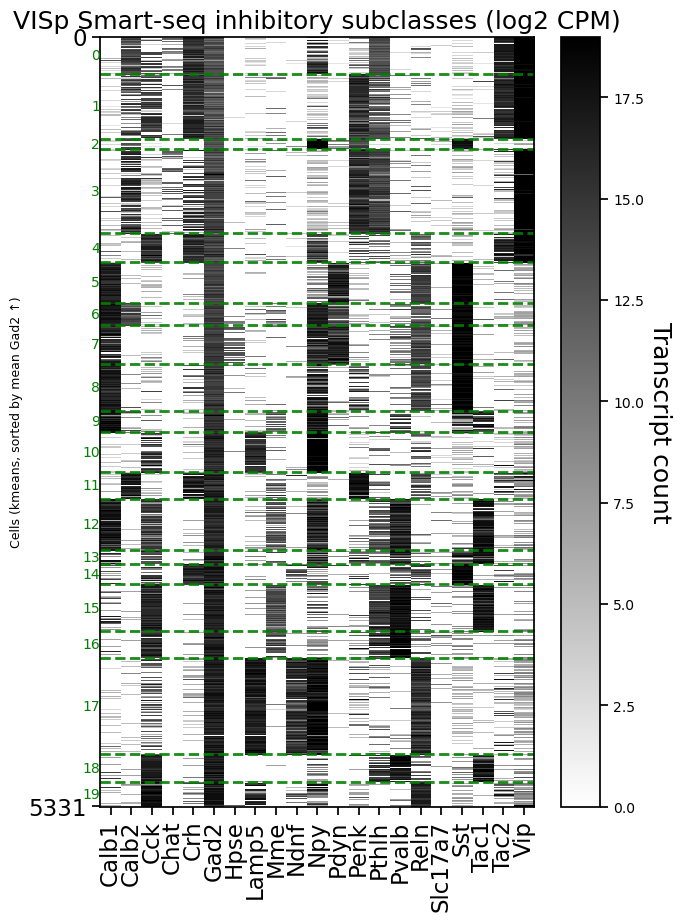

In [25]:
import aind_hcr_qc.viz as viz
adata_log_inh = filtered_log["inhibitory"]
viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh.X, columns=adata_log_inh.var_names, index=adata_log_inh.obs_names),
    k=20, fig_size=(7, 10), title="VISp Smart-seq inhibitory subclasses (log2 CPM)",
    clip_range=(0, 5000))


# Explore by subclass

In [26]:
adata_log_inh[:, "Vip"].X.flatten() > 1

array([ True,  True,  True, ..., False, False, False], shape=(5331,))

(<Figure size 700x500 with 2 Axes>,
 array([ 0,  0,  0, ..., 14, 14, 14], shape=(1576,)),
 Index(['F2S4_160415_016_H01', 'F2S4_160419_011_B01', 'F2S4_160419_012_F01',
        'F2S4_160419_011_C01', 'F2S4_160419_018_H01', 'F2S4_160406_001_F01',
        'F2S4_160422_024_C01', 'F2S4_160429_007_E01', 'F2S4_160406_003_A01',
        'F2S4_160406_003_B01',
        ...
        'F1S4_180124_308_E01', 'F2S4_170803_016_F01', 'F2S4_160413_008_E01',
        'F2S4_170828_002_A01', 'F2S4_170828_005_A01', 'F1S4_160108_003_G01',
        'F2S4_170828_005_H01', 'F2S4_171109_008_B01', 'F2S4_171201_006_A01',
        'FYS4_171004_103_B01'],
       dtype='object', name='sample_name', length=1576))

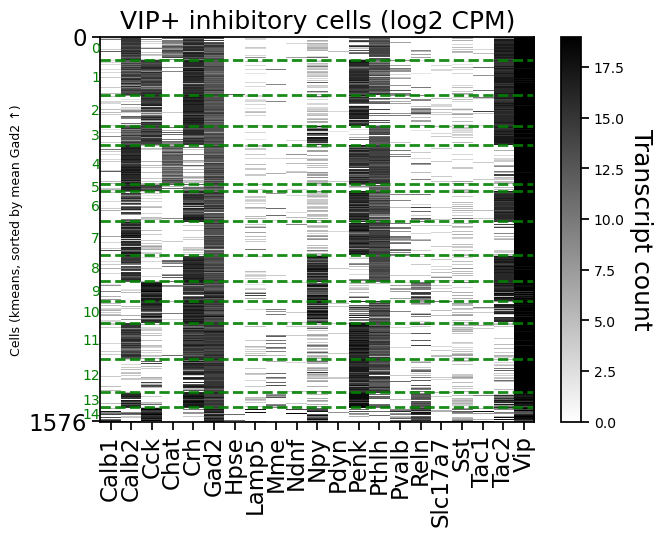

In [75]:
# redo clustering on cells with high VIP counts
vip_mask = adata_log_inh[:, "Vip"].X.flatten() > 12
adata_log_inh_vip = adata_log_inh[vip_mask].copy()
viz.plot_cell_x_gene_clustered(
    pd.DataFrame(adata_log_inh_vip.X, columns=adata_log_inh_vip.var_names, index=adata_log_inh_vip.obs_names),
    k=15, fig_size=(7, 5), title="VIP+ inhibitory cells (log2 CPM)",
    clip_range=(0, 5000))


In [63]:
adata_log_inh_vip.obs

,class,subclass,cluster,brain_region,brain_subregion,leiden,leiden_test
sample_name,,,,,,,
F1S4_160108_001_A01,GABAergic,Vip,Vip Arhgap36 Hmcn1,VISp,L2/3,7,8
F1S4_160108_001_D01,GABAergic,Vip,Vip Crispld2 Htr2c,VISp,L2/3,1,2
F1S4_160108_001_E01,GABAergic,Lamp5,Lamp5 Plch2 Dock5,VISp,L2/3,4,0
F1S4_160108_002_C01,GABAergic,Vip,Vip Lect1 Oxtr,VISp,L2/3,5,3
F1S4_160108_002_D01,GABAergic,Vip,Vip Crispld2 Kcne4,VISp,L2/3,1,2
...,...,...,...,...,...,...,...
FYS4_171003_504_E01,GABAergic,Vip,Vip Lect1 Oxtr,VISp,L1-L4,0,9
FYS4_171003_504_F01,GABAergic,Vip,Vip Crispld2 Kcne4,VISp,L1-L4,6,6
FYS4_171003_508_E01,GABAergic,Vip,Vip Igfbp4 Mab21l1,VISp,L5-L6,7,8


In [73]:
from sklearn.metrics import adjusted_rand_score

sweep_results = []
for n_neighbors in [5, 10, 15, 20, 30]:
    for resolution in [0.3, 0.5, 0.8, 1.0, 1.5]:
        sc.pp.neighbors(adata_log_inh_vip, use_rep="X", n_neighbors=n_neighbors)
        sc.tl.leiden(adata_log_inh_vip, resolution=resolution, key_added="leiden_test")
        ari = adjusted_rand_score(
            adata_log_inh_vip.obs["cluster"],
            adata_log_inh_vip.obs["leiden_test"],
        )
        sweep_results.append({"n_neighbors": n_neighbors, "resolution": resolution, "ari": ari})

sweep_df = pd.DataFrame(sweep_results).sort_values("ari", ascending=False)
best = sweep_df.iloc[0]
print(f"Best: n_neighbors={int(best.n_neighbors)}, resolution={best.resolution:.1f}, ARI={best.ari:.3f}")
sweep_df.head(10)


/tmp/ipykernel_413919/1333970399.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_log_inh_vip, resolution=resolution, key_added="leiden_test")
/tmp/ipykernel_413919/1333970399.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_log_inh_v

Best: n_neighbors=30, resolution=1.0, ARI=0.320


,n_neighbors,resolution,ari
23,30,1.0,0.320128
22,30,0.8,0.307171
21,30,0.5,0.304603
20,30,0.3,0.304321
16,20,0.5,0.303306
17,20,0.8,0.303247
24,30,1.5,0.301530
18,20,1.0,0.296349
6,10,0.5,0.291401
12,15,0.8,0.286809


In [71]:
best

n_neighbors    30.000000
resolution      1.000000
ari             0.320183
Name: 23, dtype: float64

In [77]:
# run final clustering with best parameters from sweep
best_n_neighbors = int(best.n_neighbors)
best_resolution = best.resolution

sc.pp.neighbors(adata_log_inh_vip, use_rep="X", n_neighbors=best_n_neighbors)
sc.tl.leiden(adata_log_inh_vip, resolution=best_resolution)

# after running the sweep and best clustering:
n_leiden_clusters = adata_log_inh_vip.obs["leiden"].nunique()
print(f"Leiden found {n_leiden_clusters} clusters → use as k for k-means")


/tmp/ipykernel_413919/2183821413.py:6: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_log_inh_vip, resolution=best_resolution)


Leiden found 15 clusters → use as k for k-means


In [78]:
sc.tl.umap(adata_log_inh_vip)

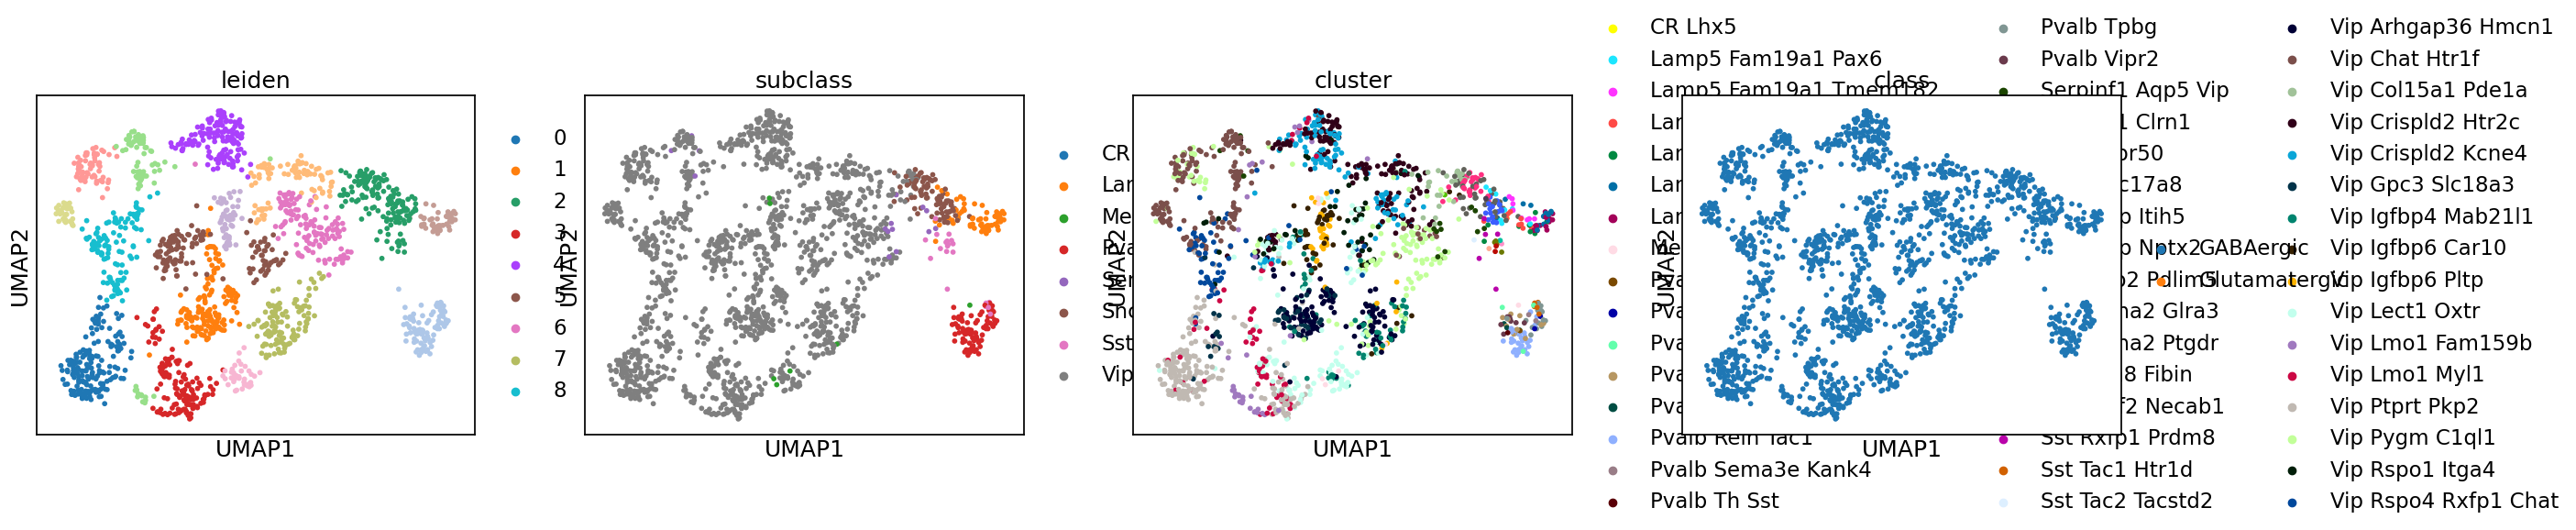

In [68]:
umap_vip = sc.pl.umap(adata_log_inh_vip, color=["leiden", "subclass", "cluster", "class"], show=False)


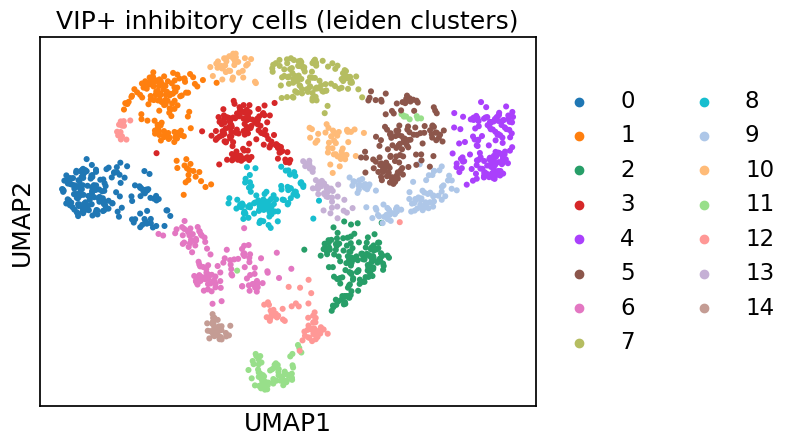

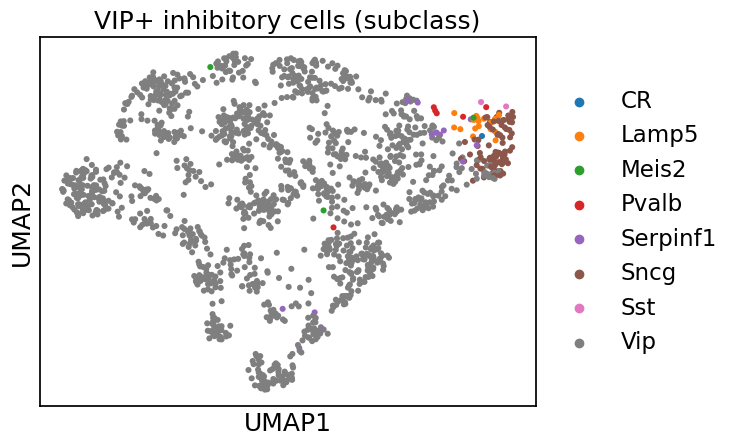

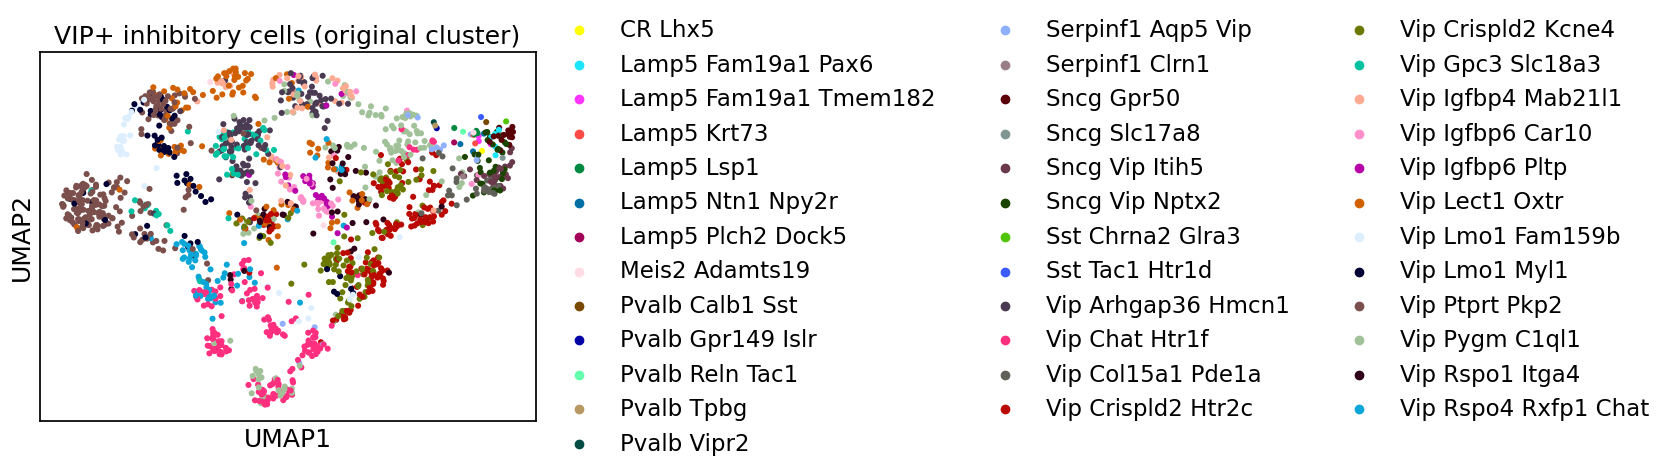

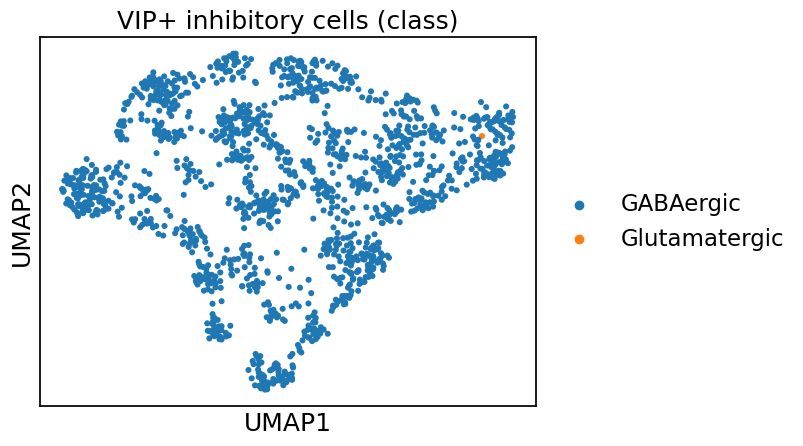

In [79]:
# umap_vip
# plt each separately to avoid legend issues
umap_vip_leiden = sc.pl.umap(adata_log_inh_vip,
    color="leiden", title="VIP+ inhibitory cells (leiden clusters)", show=False)
umap_vip_subclass = sc.pl.umap(adata_log_inh_vip,
    color="subclass", title="VIP+ inhibitory cells (subclass)", show=False)
umap_vip_cluster = sc.pl.umap(adata_log_inh_vip,
    color="cluster", title="VIP+ inhibitory cells (original cluster)", show=False)
umap_vip_class = sc.pl.umap(adata_log_inh_vip,
    color="class", title="VIP+ inhibitory cells (class)", show=False)

